In [34]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

class GeneradorSegmentacionTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        self.num_clases = 19
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_X = []
        batch_Y = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            parche_X = np.load(os.path.join(self.carpeta, nom_X)).astype(np.float32)
            parche_Y = np.load(os.path.join(self.carpeta, nom_Y)).astype(np.int32)
            
            if parche_X.shape[0] == 4:
                parche_X = np.transpose(parche_X, (1, 2, 0))
            
            parche_X = parche_X[:48, :48, :]
            parche_Y = parche_Y[:48, :48]
            
            mask_one_hot = tf.one_hot(parche_Y, depth=self.num_clases, dtype=tf.float32).numpy()
            
            batch_X.append(parche_X)
            batch_Y.append(mask_one_hot)
            
        if len(batch_X) == 0:
            return (np.zeros((1, 48, 48, 4), dtype=np.float32), 
                    np.zeros((1, 48, 48, self.num_clases), dtype=np.float32))
            
        return np.array(batch_X), np.array(batch_Y)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

carpeta_dataset = r"D:\TFG\dataset_parches_50x50"
todos_los_X_total = sorted([f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')])

np.random.seed(4215) 
np.random.shuffle(todos_los_X_total)
archivos_prueba = todos_los_X_total[:150000]

archivos_train, archivos_val = train_test_split(archivos_prueba, test_size=0.2, random_state=42)

generador_train = GeneradorSegmentacionTFG(carpeta_dataset, archivos_train, batch_size=64, shuffle=True)
generador_val = GeneradorSegmentacionTFG(carpeta_dataset, archivos_val, batch_size=64, shuffle=False)

def build_unet_autoencoder(input_shape, num_classes):
    entradas = layers.Input(shape=input_shape)
    
    init = 'he_normal'
    reg = tf.keras.regularizers.l2(1e-6)
    
    x = layers.Normalization(axis=-1)(entradas)
    
    # ENCODER
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(x)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c1)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c2)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # Cuello de botella
    bottleneck = layers.Conv2D(128, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p2)
    bottleneck = layers.BatchNormalization()(bottleneck)
    bottleneck = layers.Activation('gelu')(bottleneck)
    
    # DECODER
    u3 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(bottleneck)
    merge3 = layers.concatenate([u3, c2]) 
    c3 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge3)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('gelu')(c3)
    
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(c3)
    merge4 = layers.concatenate([u4, c1]) 
    c4 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge4)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('gelu')(c4)
    
    salidas = layers.Conv2D(num_classes, (1, 1), activation='softmax', kernel_initializer=init)(c4)
    
    return models.Model(inputs=entradas, outputs=salidas)

model = build_unet_autoencoder((48, 48, 4), 19)

def dice_loss_multiclass(y_true, y_pred):
    y_pred = tf.nn.softmax(y_pred, axis=-1)
    
    smooth = 1e-5
    
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    area_true = tf.reduce_sum(y_true, axis=[1, 2])
    area_pred = tf.reduce_sum(y_pred, axis=[1, 2])
    
    dice_coef = (2.0 * intersection + smooth) / (area_true + area_pred + smooth)
    
    return 1.0 - tf.reduce_mean(dice_coef)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3, clipvalue=0.5),
    loss=dice_loss_multiclass, 
    metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')] 
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=40,
    callbacks=mis_callbacks
)

KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

class GeneradorSegmentacionTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        # Cambiado a 20 porque la clase '19' requiere que el vector tenga longitud 20 (índices 0 al 19)
        self.num_clases = 20
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_X = []
        batch_Y = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            parche_X = np.load(os.path.join(self.carpeta, nom_X)).astype(np.float32)
            parche_Y = np.load(os.path.join(self.carpeta, nom_Y)).astype(np.int32)
            
            if parche_X.shape[0] == 4:
                parche_X = np.transpose(parche_X, (1, 2, 0))
            
            parche_X = parche_X[:48, :48, :]
            parche_Y = parche_Y[:48, :48]
            
            # Si se coló algún código corrupto fuera del rango [0, 19], lo forzamos a ser 19
            parche_Y = np.where((parche_Y >= 0) & (parche_Y <= 19), parche_Y, 19)
            
            mask_one_hot = tf.one_hot(parche_Y, depth=self.num_clases, dtype=tf.float32).numpy()
            
            batch_X.append(parche_X)
            batch_Y.append(mask_one_hot)
            
        if len(batch_X) == 0:
            return (np.zeros((1, 48, 48, 4), dtype=np.float32), 
                    np.zeros((1, 48, 48, self.num_clases), dtype=np.float32))
            
        return np.array(batch_X), np.array(batch_Y)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# --- 1. FILTRADO INTELIGENTE PREVIO DEL DATASET (EVITAR PARCHES VACÍOS) ---
carpeta_dataset = r"D:\TFG\dataset_parches_50x50"

print("Paso 1: Escaneando nombres de archivos en el disco...", flush=True)
# os.listdir solo lee texto (los nombres), esto tarda menos de 2 segundos para 1 millón
todos_los_X_total = [f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')]

# Mezclamos todos los nombres aleatoriamente
np.random.seed(4215) 
np.random.shuffle(todos_los_X_total)

print("Paso 2: Buscando parches útiles reales hasta completar tu cupo...", flush=True)
archivos_prueba = []
cupo_deseado = 150000  

for nom_X in todos_los_X_total:
    if len(archivos_prueba) >= cupo_deseado:
        break 
        
    nom_Y = nom_X.replace('_X.npy', '_Y.npy')
    try:
        # Cargamos solo si el archivo existe
        parche_y = np.load(os.path.join(carpeta_dataset, nom_Y))
        conteos = np.bincount(parche_y.ravel(), minlength=20)
        
        # Si NO está dominado por el vacío (19), directo a la lista de entrenamiento
        if np.argmax(conteos[:20]) != 19:
            archivos_prueba.append(nom_X)
    except Exception:
        continue

print(f"¡Listo! Dataset seleccionado con {len(archivos_prueba):,} parches de alta calidad.")

archivos_train, archivos_val = train_test_split(archivos_prueba, test_size=0.2, random_state=42)

generador_train = GeneradorSegmentacionTFG(carpeta_dataset, archivos_train, batch_size=32, shuffle=True)
generador_val = GeneradorSegmentacionTFG(carpeta_dataset, archivos_val, batch_size=32, shuffle=False)

# --- 2. CONFIGURACIÓN DE LA ARQUITECTURA DE LA U-NET (20 CLASES DE SALIDA) ---
def build_unet_autoencoder(input_shape, num_classes):
    entradas = layers.Input(shape=input_shape)
    init = 'glorot_uniform'
    reg = tf.keras.regularizers.l2(1e-6)
    
    x = layers.Normalization(axis=-1)(entradas)
    
    # ENCODER
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(x)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c1)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c2)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # BOTTLENECK
    bottleneck = layers.Conv2D(128, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p2)
    bottleneck = layers.BatchNormalization()(bottleneck)
    bottleneck = layers.Activation('gelu')(bottleneck)
    
    # DECODER
    u3 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(bottleneck)
    merge3 = layers.concatenate([u3, c2]) 
    c3 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge3)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('gelu')(c3)
    
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(c3)
    merge4 = layers.concatenate([u4, c1]) 
    c4 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge4)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('gelu')(c4)
    
    # Cambiado a Softmax nativo directo (obligatorio para la entropía cruzada pesada)
    salidas = layers.Conv2D(num_classes, (1, 1), activation='softmax', kernel_initializer=init)(c4)
    
    return models.Model(inputs=entradas, outputs=salidas)

# Configuramos la red para manejar el mapa completo de salidas de tamaño 20
model = build_unet_autoencoder((48, 48, 4), 20)

# --- 3. FUNCIÓN DE PÉRDIDA PESADA PERSONALIZADA (IGNORANDO EL CANAL 19) ---
# Pesos calculados exactamente con la inversa de la frecuencia de tus 8 clases reales de la meseta.
# El canal 19 tiene PESO 0.0, lo que significa que la red ignorará por completo los errores en píxeles vacíos.
PESOS_REALES_MESETA = tf.constant([
    23.4,  # Clase 0
    69.1,  # Clase 1
    1.0,   # Clase 2 (Base mayoritaria de la meseta central)
    4.0,   # Clase 3
    19.2,  # Clase 4
    7.6,   # Clase 5
    11.0,  # Clase 6
    8.3,   # Clase 7
    1.0,   # Clase 8 (Vacia en tu zona)
    1.0,   # Clase 9 (Vacia en tu zona)
    1.0,   # Clase 10 (Vacia en tu zona)
    1.0,   # Clase 11 (Residual)
    1.0,   # Clase 12 (Vacia en tu zona)
    1.0,   # Clase 13 (Vacia en tu zona)
    1.0,   # Clase 14 (Vacia en tu zona)
    1.0,   # Clase 15 (Vacia en tu zona)
    1.0,   # Clase 16 (Vacia en tu zona)
    1.0,   # Clase 17 (Vacia en tu zona)
    1.0,   # Clase 18 (Vacia en tu zona)
    0.0    # Clase 19 (PESO CERO -> El No Data no penaliza ni modifica gradientes)
], dtype=tf.float32)

def loss_cross_entropy_pesada(y_true, y_pred):
    smooth = 1e-5
    y_pred = tf.clip_by_value(y_pred, smooth, 1.0 - smooth)
    
    # Entropía cruzada píxel a píxel
    cce_por_pixel = -y_true * tf.math.log(y_pred)
    
    # Aplicamos la máscara de pesos (incluyendo el cero para anular la clase 19)
    cce_pesada = cce_por_pixel * PESOS_REALES_MESETA
    
    return tf.reduce_mean(tf.reduce_sum(cce_pesada, axis=-1))

# --- 4. COMPILACIÓN Y ENTRENAMIENTO ---
# Cambiamos Dice Loss por Entropía Cruzada Pesada (evita gradientes nulos del softmax)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3, clipvalue=0.5),
    loss=loss_cross_entropy_pesada, 
    metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')] 
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=40,
    callbacks=mis_callbacks
)

Paso 1: Escaneando nombres de archivos en el disco...
Paso 2: Buscando parches útiles reales hasta completar tu cupo...
¡Listo! Dataset seleccionado con 50,000 parches de alta calidad.
Epoch 1/40
1250/1250 [==============================] - 544s 430ms/step - loss: 6.6251 - accuracy: 0.3958 - val_loss: 7.3098 - val_accuracy: 0.3448 - lr: 0.0010
Epoch 2/40
1250/1250 [==============================] - 171s 137ms/step - loss: 5.5864 - accuracy: 0.4486 - val_loss: 6.6372 - val_accuracy: 0.2352 - lr: 0.0010
Epoch 3/40
1250/1250 [==============================] - 172s 138ms/step - loss: 5.3617 - accuracy: 0.4821 - val_loss: 8.1616 - val_accuracy: 0.4984 - lr: 0.0010
Epoch 4/40
1250/1250 [==============================] - 170s 136ms/step - loss: 5.1630 - accuracy: 0.4996 - val_loss: 6.0387 - val_accuracy: 0.5141 - lr: 0.0010
Epoch 5/40
1250/1250 [==============================] - 170s 136ms/step - loss: 5.1111 - accuracy: 0.5076 - val_loss: 7.6793 - val_accuracy: 0.3626 - lr: 0.0010
Epoch 6/40

In [ ]:
model.save("segundo_modelo_att1.keras")

In [41]:
model = tf.keras.models.load_model("segundo_modelo_att1.keras", compile=False)

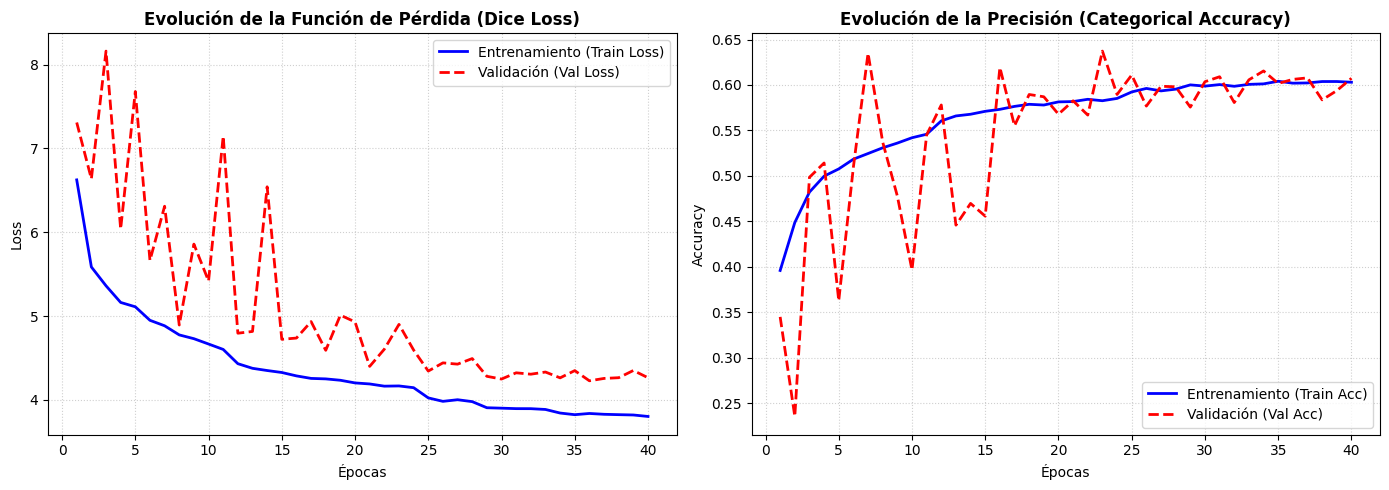

In [42]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño del gráfico con un estilo limpio
plt.figure(figsize=(14, 5))
epochs = range(1, len(history.history['loss']) + 1)

# --- GRÁFICO 1: LOSS (PÉRDIDA) ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], 'b-', label='Entrenamiento (Train Loss)', linewidth=2)
plt.plot(epochs, history.history['val_loss'], 'r--', label='Validación (Val Loss)', linewidth=2)
plt.title('Evolución de la Función de Pérdida (Dice Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

# --- GRÁFICO 2: ACCURACY (PRECISIÓN) ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['accuracy'], 'b-', label='Entrenamiento (Train Acc)', linewidth=2)
plt.plot(epochs, history.history['val_accuracy'], 'r--', label='Validación (Val Acc)', linewidth=2)
plt.title('Evolución de la Precisión (Categorical Accuracy)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

# 2. Ajustar espacios y guardar la imagen para la memoria del TFG
plt.tight_layout()
plt.savefig('curvas_entrenamiento_tfg.png', dpi=300) # Se guarda automáticamente en alta calidad
plt.show()

Cargando parches desde generador_val...
Generando predicciones para 3200 parches...
100/100 [==============================] - 2s 20ms/step
Aplanando matrices píxel a píxel...


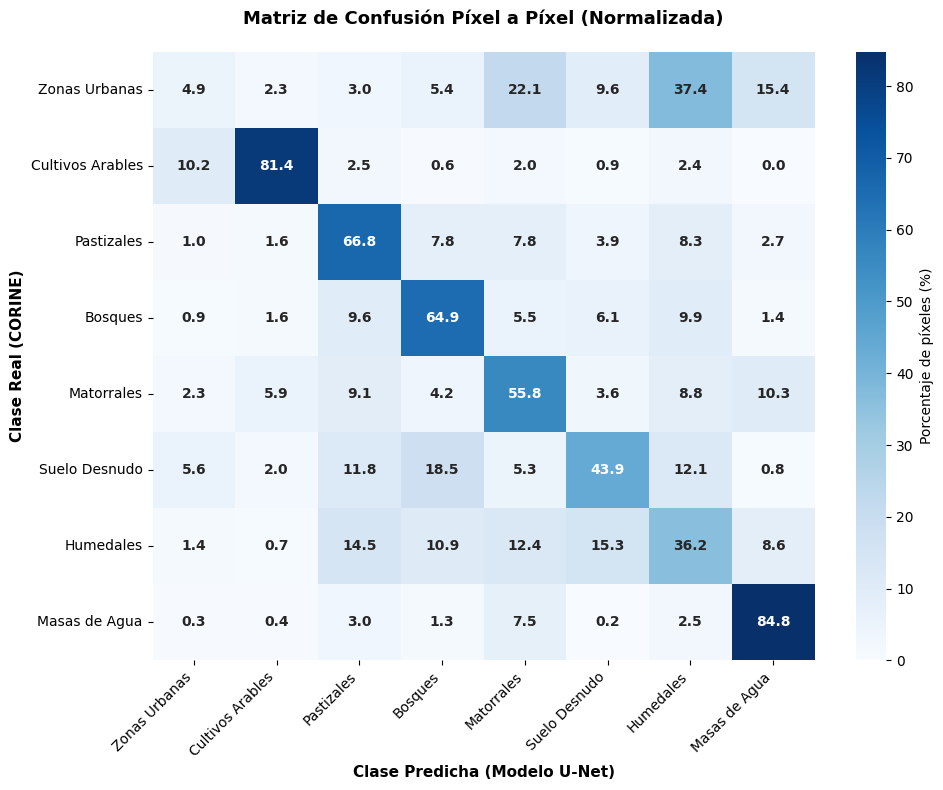

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Tus clases dominantes (asegúrate de que correspondan a los índices 0-7)
class_names = [
    'Zonas Urbanas', 'Cultivos Arables', 'Pastizales', 'Bosques', 
    'Matorrales', 'Suelo Desnudo', 'Humedales', 'Masas de Agua'
]

# 2. Extraer una muestra controlada de imágenes y máscaras de validación
print("Cargando parches desde generador_val...")
images_list = []
labels_list = []

# Evaluamos con los primeros 50 batches para proteger la memoria RAM
num_batches_eval = min(50, len(generador_val)) 

for i in range(num_batches_eval): 
    images, masks = generador_val[i]
    images_list.append(images)
    labels_list.append(masks)

# Unimos en arrays nativos
X_val_sample = np.concatenate(images_list, axis=0)
y_true_sample = np.concatenate(labels_list, axis=0)

# 3. Generar predicciones con el modelo cargado/entrenado
print(f"Generando predicciones para {X_val_sample.shape[0]} parches...")
predicciones = model.predict(X_val_sample)

# 4. Aplanar matrices píxel a píxel
print("Aplanando matrices píxel a píxel...")
y_true_flat = y_true_sample.argmax(axis=-1).flatten()
y_pred_flat = predicciones.argmax(axis=-1).flatten()

# 5. Calcular la matriz únicamente para tus 8 clases de interés
num_clases_interes = len(class_names)
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=range(num_clases_interes))

# Normalizar por filas (porcentaje de acierto por clase)
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

# 6. Dibujar el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized * 100, 
    annot=True, 
    fmt='.1f', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names,
    cbar_kws={'label': 'Porcentaje de píxeles (%)'},
    annot_kws={'size': 10, 'weight': 'bold'}
)

plt.title('Matriz de Confusión Píxel a Píxel (Normalizada)', fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Clase Real (CORINE)', fontsize=11, fontweight='bold')
plt.xlabel('Clase Predicha (Modelo U-Net)', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Guardar en alta resolución para tu memoria
plt.savefig('matriz_confusion_pixel_tfg.png', dpi=300)
plt.show()

Pasando el parche parche_451556 por la U-Net...
1/1 [==============================] - 0s 85ms/step


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\1146204019.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


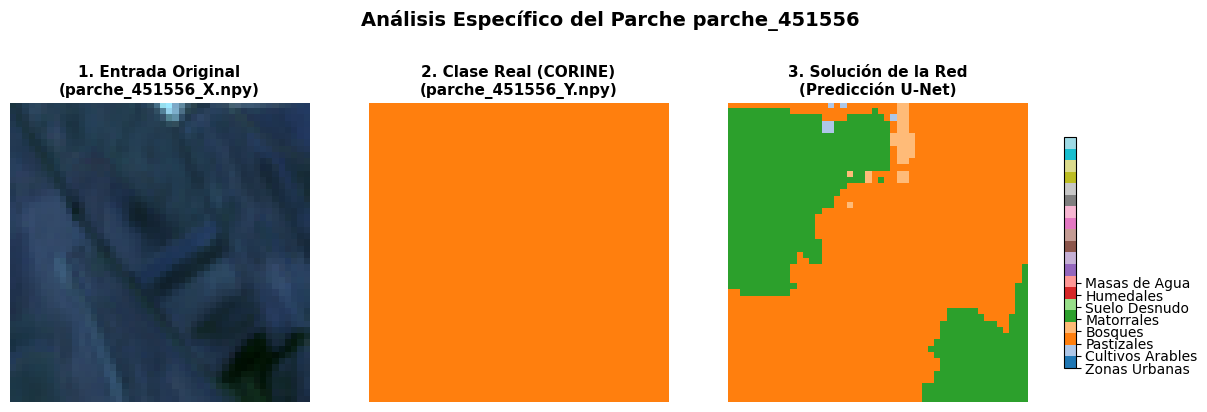

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Configurar las rutas y el identificador de la imagen
carpeta_dataset = r"D:\TFG\dataset_parches_50x50"  # Usando tu ruta original de los parches
id_imagen = "parche_451556"

archivo_x = os.path.join(carpeta_dataset, f"{id_imagen}_X.npy")
archivo_y = os.path.join(carpeta_dataset, f"{id_imagen}_Y.npy")

# Nombres de tus clases principales para la leyenda
class_names = [
    'Zonas Urbanas', 'Cultivos Arables', 'Pastizales', 'Bosques', 
    'Matorrales', 'Suelo Desnudo', 'Humedales', 'Masas de Agua'
]

# 2. Cargar los archivos .npy
if os.path.exists(archivo_x) and os.path.exists(archivo_y):
    img_original = np.load(archivo_x).astype(np.float32)
    mascara_real_raw = np.load(archivo_y).astype(np.int32)
    
    # Si la imagen viene transpuesta (canales primero), la corregimos como en tu generador
    if img_original.shape[0] == 4:
        img_original = np.transpose(img_original, (1, 2, 0))
    
    # Reducir las dimensiones a 48x48 (Tal cual hace tu generador)
    img_recortada = img_original[:48, :48, :]
    
    # CORRECCIÓN AQUÍ: Al ser bidimensional, indexamos solo alto y ancho [:48, :48]
    mascara_real = mascara_real_raw[:48, :48]
    
    # Filtro de seguridad por si hay algún código corrupto en este parche
    mascara_real = np.where((mascara_real >= 0) & (mascara_real <= 19), mascara_real, 19)
    
    # 3. Preparar la imagen para el modelo (añadir dimensión de batch: [1, 48, 48, 4])
    img_batch = np.expand_dims(img_recortada, axis=0)
    
    # Generar la predicción de la red
    print(f"Pasando el parche {id_imagen} por la U-Net...")
    prediccion_raw = model.predict(img_batch)
    # Extraer la clase con mayor probabilidad para cada píxel
    mascara_pred = prediccion_raw[0].argmax(axis=-1)
    
    # 4. Configurar la visualización en Matplotlib
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Subplot 1: Imagen Original (Canales RGB)
    img_rgb = img_recortada[:, :, :3]
    if img_rgb.max() > 1.0:
        img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-9)
        
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"1. Entrada Original\n({id_imagen}_X.npy)", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    # Usamos una paleta cualitativa para las clases de segmentación (máximo 20 clases)
    cmap_segmentacion = plt.cm.get_cmap('tab20', 20)
    
    # Subplot 2: Máscara Real de Corine
    im_real = axes[1].imshow(mascara_real, cmap=cmap_segmentacion, vmin=0, vmax=19)
    axes[1].set_title(f"2. Clase Real (CORINE)\n({id_imagen}_Y.npy)", fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    # Subplot 3: Solución de la Red (Predicción)
    im_pred = axes[2].imshow(mascara_pred, cmap=cmap_segmentacion, vmin=0, vmax=19)
    axes[2].set_title("3. Solución de la Red\n(Predicción U-Net)", fontsize=11, fontweight='bold')
    axes[2].axis('off')
    
    # Añadir barra de color a la derecha
    cbar = fig.colorbar(im_pred, ax=axes.ravel().tolist(), shrink=0.6, location='right', pad=0.03)
    cbar.set_ticks(range(len(class_names)))
    cbar.set_ticklabels(class_names)
    
    plt.suptitle(f"Análisis Específico del Parche {id_imagen}", fontsize=14, fontweight='bold', y=0.98)
    
    # Guardar el resultado para la memoria del TFG
    plt.savefig(f'resultado_especifico_{id_imagen}.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print(f"Error: No se encontraron los archivos en la ruta especificada. Verifica D:\\TFG\\dataset_parches_50x50")

Escaneando la carpeta de parches...
¡Listo! Se han seleccionado 10 parches al azar. Procesando...
[1/10] Procesando parche: parche_771639...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


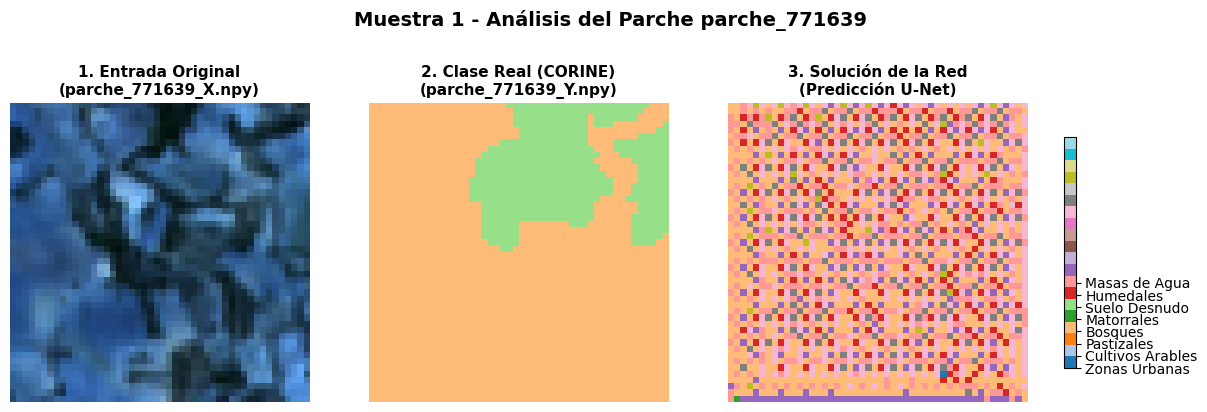

[2/10] Procesando parche: parche_776394...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


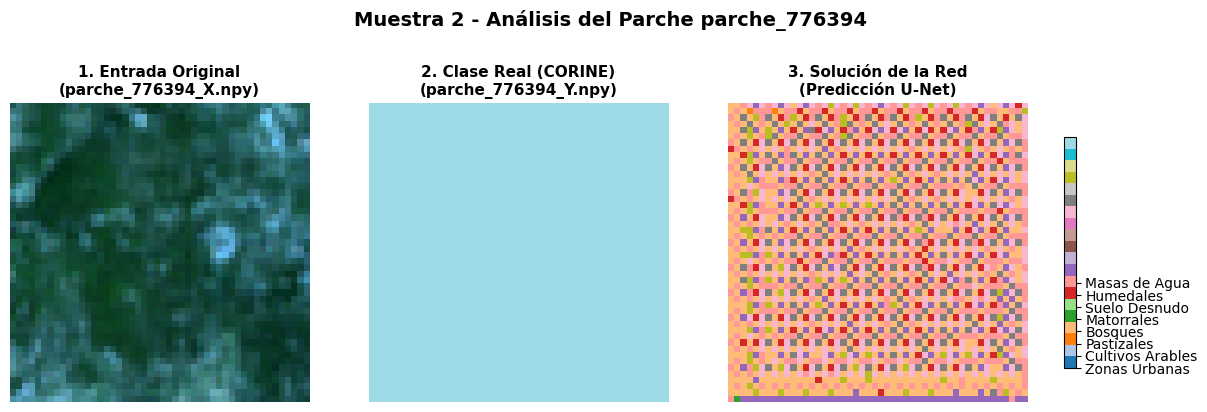

[3/10] Procesando parche: parche_1013760...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


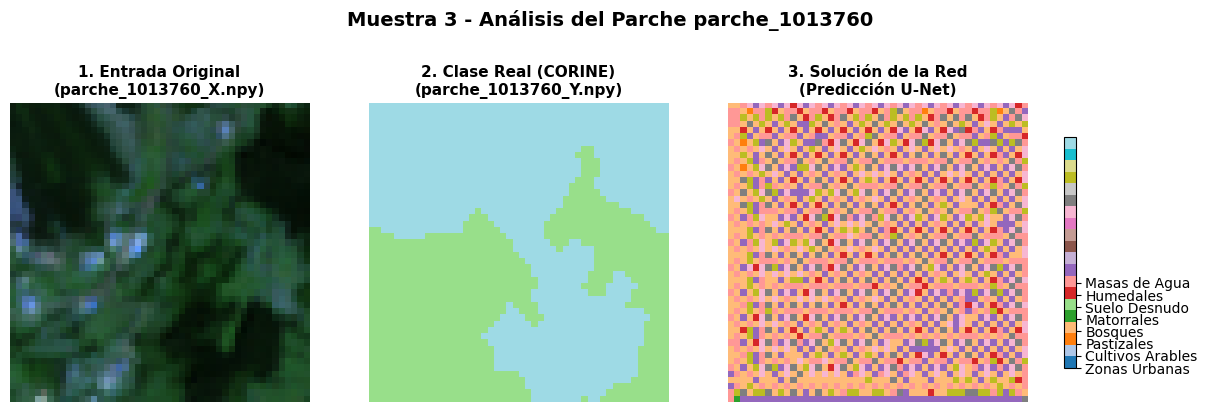

[4/10] Procesando parche: parche_1119015...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


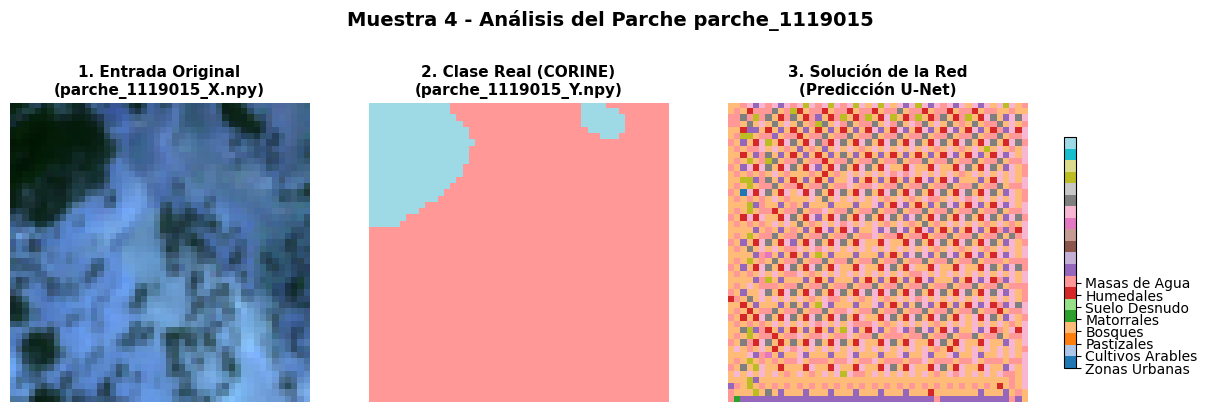

[5/10] Procesando parche: parche_059229...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


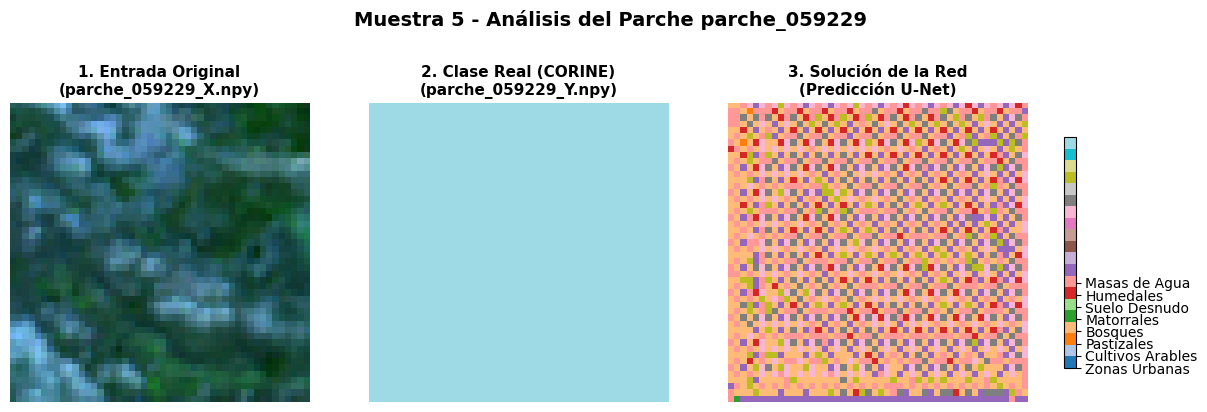

[6/10] Procesando parche: parche_229340...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


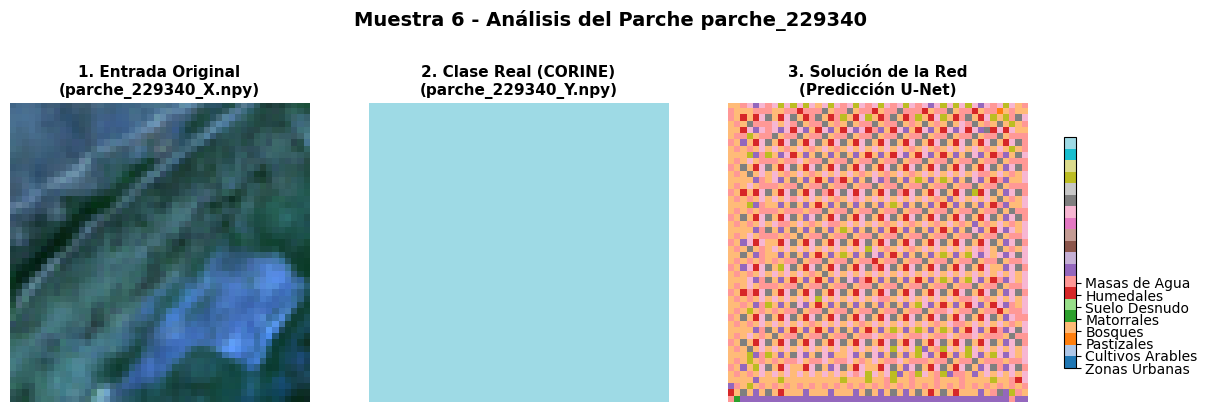

[7/10] Procesando parche: parche_947063...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


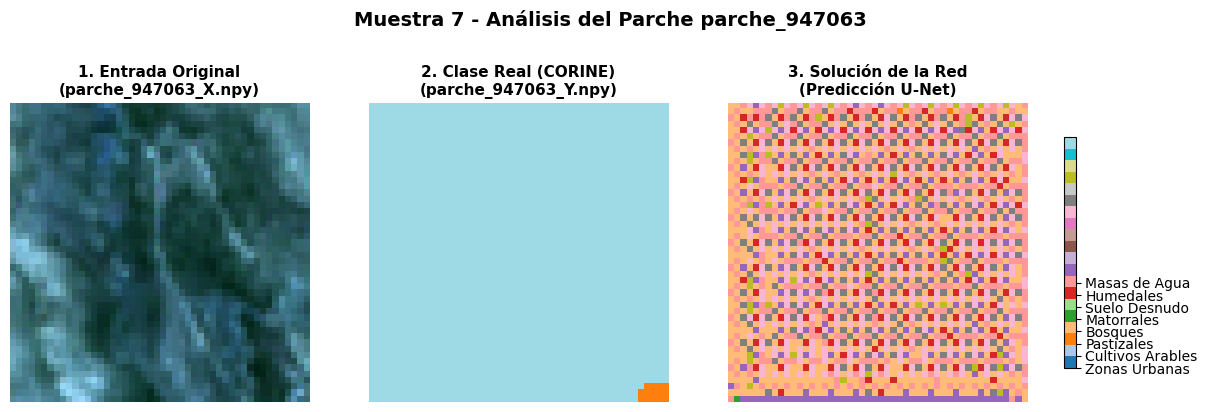

[8/10] Procesando parche: parche_360852...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


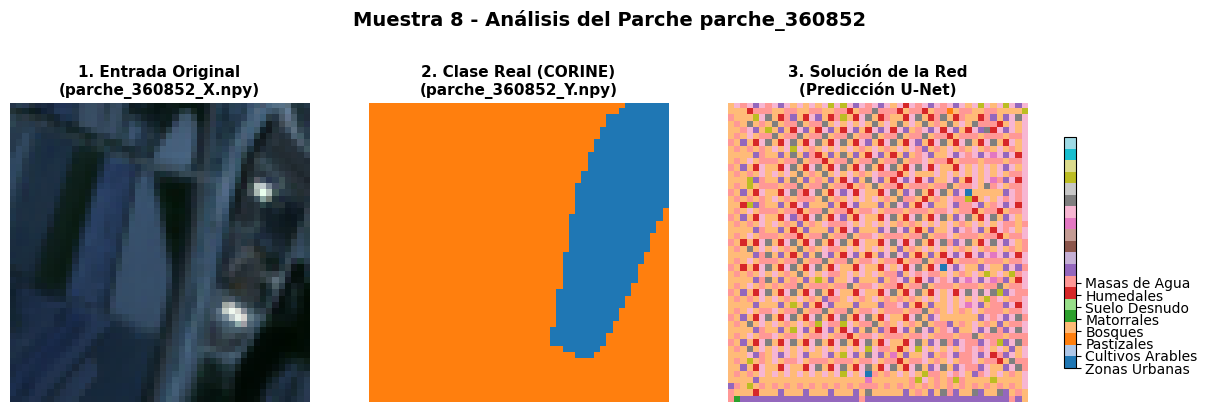

[9/10] Procesando parche: parche_1125582...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


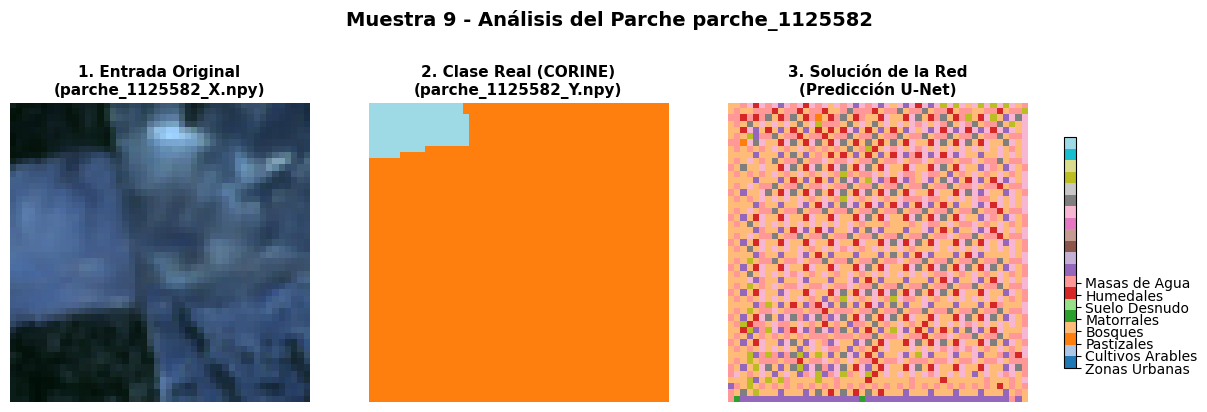

[10/10] Procesando parche: parche_1082267...


C:\Users\joral\AppData\Local\Temp\ipykernel_3956\2718749841.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_segmentacion = plt.cm.get_cmap('tab20', 20)


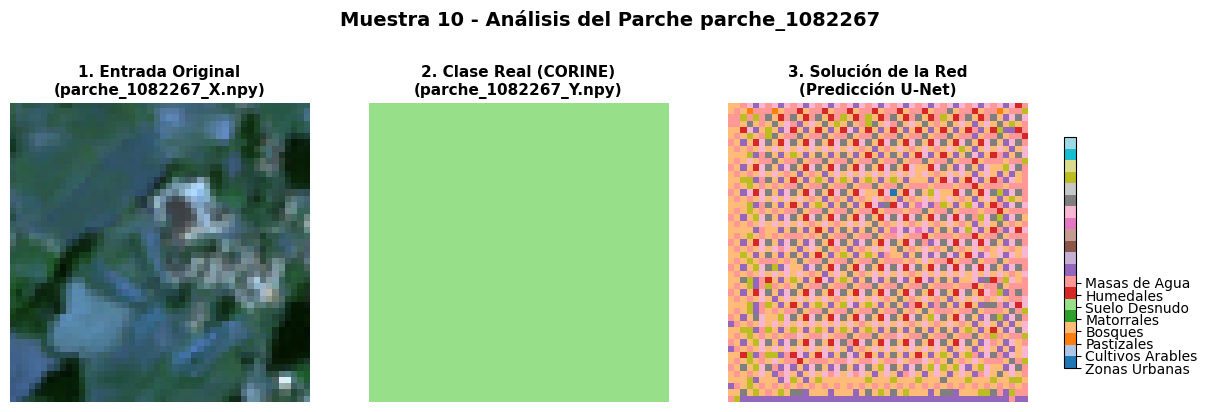

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# 1. Configurar las rutas
carpeta_dataset = r"D:\TFG\dataset_parches_50x50"

# Nombres de tus clases principales para la leyenda
class_names = [
    'Zonas Urbanas', 'Cultivos Arables', 'Pastizales', 'Bosques', 
    'Matorrales', 'Suelo Desnudo', 'Humedales', 'Masas de Agua'
]

# 2. Escanear la carpeta y extraer todos los IDs disponibles
print("Escaneando la carpeta de parches...")
todos_los_archivos = os.listdir(carpeta_dataset)
# Filtramos solo los archivos de imagen (_X.npy) y extraemos su ID (quitando el '_X.npy')
lista_ids = [f.replace('_X.npy', '') for f in todos_los_archivos if f.endswith('_X.npy')]

# Validar que tengamos suficientes parches
if len(lista_ids) < 10:
    ids_seleccionados = lista_ids
else:
    # Seleccionar 10 IDs aleatorios sin repetir
    ids_seleccionados = random.sample(lista_ids, 10)

print(f"¡Listo! Se han seleccionado 10 parches al azar. Procesando...")

# 3. Bucle para procesar y pintar cada parche seleccionado
for idx, id_imagen in enumerate(ids_seleccionados, start=1):
    archivo_x = os.path.join(carpeta_dataset, f"{id_imagen}_X.npy")
    archivo_y = os.path.join(carpeta_dataset, f"{id_imagen}_Y.npy")
    
    # Doble verificación de que ambos archivos existen
    if os.path.exists(archivo_x) and os.path.exists(archivo_y):
        print(f"[{idx}/10] Procesando parche: {id_imagen}...")
        
        img_original = np.load(archivo_x).astype(np.float32)
        mascara_real_raw = np.load(archivo_y).astype(np.int32)
        
        # Si la imagen viene transpuesta (canales primero), la corregimos
        if img_original.shape[0] == 4:
            img_original = np.transpose(img_original, (1, 2, 0))
        
        # Reducir las dimensiones a 48x48
        img_recortada = img_original[:48, :48, :]
        mascara_real = mascara_real_raw[:48, :48]
        
        # Filtro de seguridad por si hay algún código corrupto en este parche
        mascara_real = np.where((mascara_real >= 0) & (mascara_real <= 19), mascara_real, 19)
        
        # Preparar la imagen para el modelo (añadir dimensión de batch)
        img_batch = np.expand_dims(img_recortada, axis=0)
        
        # Generar la predicción de la red
        prediccion_raw = model.predict(img_batch, verbose=0)  # verbose=0 para no saturar la consola
        mascara_pred = prediccion_raw[0].argmax(axis=-1)
        
        # 4. Configurar la visualización en Matplotlib
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        # Subplot 1: Imagen Original (Canales RGB)
        img_rgb = img_recortada[:, :, :3]
        if img_rgb.max() > 1.0:
            img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-9)
            
        axes[0].imshow(img_rgb)
        axes[0].set_title(f"1. Entrada Original\n({id_imagen}_X.npy)", fontsize=11, fontweight='bold')
        axes[0].axis('off')
        
        # Paleta cualitativa para las clases de segmentación
        cmap_segmentacion = plt.cm.get_cmap('tab20', 20)
        
        # Subplot 2: Máscara Real de Corine
        im_real = axes[1].imshow(mascara_real, cmap=cmap_segmentacion, vmin=0, vmax=19)
        axes[1].set_title(f"2. Clase Real (CORINE)\n({id_imagen}_Y.npy)", fontsize=11, fontweight='bold')
        axes[1].axis('off')
        
        # Subplot 3: Solución de la Red (Predicción)
        im_pred = axes[2].imshow(mascara_pred, cmap=cmap_segmentacion, vmin=0, vmax=19)
        axes[2].set_title("3. Solución de la Red\n(Predicción U-Net)", fontsize=11, fontweight='bold')
        axes[2].axis('off')
        
        # Añadir barra de color a la derecha
        cbar = fig.colorbar(im_pred, ax=axes.ravel().tolist(), shrink=0.6, location='right', pad=0.03)
        cbar.set_ticks(range(len(class_names)))
        cbar.set_ticklabels(class_names)
        
        plt.suptitle(f"Muestra {idx} - Análisis del Parche {id_imagen}", fontsize=14, fontweight='bold', y=0.98)
        
        # Guardar cada resultado de forma independiente para tu memoria
        plt.savefig(f'resultado_aleatorio_{id_imagen}.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"Saltando {id_imagen}: No se encontró su pareja _X o _Y.")